Accompanies Section `subsec:harmonic_n2` (The $n=2$ Term: Evidence That Spots Set) of the paper, Eq. `eq:envelope_ratio`; the upper envelope is the recurrence-height result of Section `subsec:harmonic_n1` (Eqs. `eq:peak_height_ratio`, `eq:linear_peak_decay`).

# Upper and Lower Envelopes of the Single-Spot Kernel

The single-spot kernel truncated to second harmonic order (Eq. `eq:kernel_truncated`, Section `subsec:averaging`) is

$$\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau) \left[ |c_0|^2 + 2|c_1|^2\cos(\omega_0\tau) + 2|c_2|^2\cos(2\omega_0\tau) \right] = \sum_{n=0}^{2} \mathcal{K}_n(\tau),$$

where $R_\Gamma(\tau)$ is the autocorrelation of the normalized squared envelope $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$ (Eq. `eq:R_Gamma_closed`, Appendix `app:acf_trapezoid`), $c_n$ are the Fourier coefficients of the visibility function $\mathcal{V}(t)$ (Eq. `eq:cn_general`), and $\mathcal{K}_n(\tau) = \alpha_{\max}^4\, s_n |c_n|^2 R_\Gamma(\tau)\cos(n\omega_0\tau)$ with $s_0 = 1$, $s_{n\geq1} = 2$ is the single-spot, fixed-latitude form of the harmonic terms of Eq. `eq:kernel_harmonic_sum`.

The **upper envelope** is reached at integer periods $\tau = mP_{\rm eq}$, where both cosines equal $+1$:

$$k_{\rm upper}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau)\left[|c_0|^2 + 2|c_1|^2 + 2|c_2|^2\right], \qquad \frac{k_{\rm upper}(\tau)}{\mathcal{K}(0)} = \frac{R_\Gamma(\tau)}{R_\Gamma(0)},$$

so for $\kappa = 0$ the recurrence heights land exactly on the normalized $n = 0$ envelope (Eq. `eq:peak_height_ratio`).

The **lower envelope** is reached at odd half-periods $\tau = (m + \tfrac12)P_{\rm eq}$, where $\cos(\omega_0\tau) = -1$ and $\cos(2\omega_0\tau) = +1$:

$$k_{\rm lower}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau)\left[|c_0|^2 - 2|c_1|^2 + 2|c_2|^2\right].$$

The ratio $k_{\rm lower}/k_{\rm upper}$ is the fractional oscillation depth of Eq. `eq:envelope_ratio`. The paper writes it with the latitude-averaged weights $\langle|c_n|^2\rangle_\Phi$; this notebook uses the weights of a single spot at fixed $(I, \Phi)$, and checks the latitude-averaged values at the end.

**When is $k_{\rm lower}$ a true lower bound?** With $u = \cos(\omega_0\tau)$ and $\cos(2\omega_0\tau) = 2u^2 - 1$, the cosine sum is the parabola $|c_0|^2 - 2|c_2|^2 + 2|c_1|^2 u + 4|c_2|^2 u^2$, whose vertex sits at $u^* = -|c_1|^2/(4|c_2|^2)$. Its minimum over $u \in [-1, 1]$ is therefore at $u = -1$ (the half-period trough) if and only if $|c_1|^2 \geq 4|c_2|^2$. This holds for the spot below and for the latitude-averaged weights with uniform $p(\Phi)$ at every inclination ($\langle|c_1|^2\rangle_\Phi / 4\langle|c_2|^2\rangle_\Phi \geq 1.39$, smallest edge-on), but not for every individual spot: a spot that is visible only briefly near the limb has $|c_1| \approx |c_2|$, and its kernel dips below $k_{\rm lower}$ between the troughs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spotgp.envelope import _R_Gamma_symmetric                     # closed-form R_Gamma, Eq. eq:R_Gamma_closed
from spotgp.visibility import _cn_general_jax, _gauss_legendre_grid  # c_n, Eq. eq:cn_general

# Compat: np.trapezoid was added in NumPy 2.0; older versions have np.trapz
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

## Helper functions

The visibility coefficients $c_n$ (Eq. `eq:cn_general`) and the closed-form envelope autocorrelation $R_\Gamma(\tau)$ (Eq. `eq:R_Gamma_closed`) come from `spotgp` (`spotgp.visibility._cn_general_jax`, `spotgp.envelope._R_Gamma_symmetric`), the same functions the paper's kernel uses. A brute-force numerical autocorrelation of the normalized squared trapezoid $\Gamma(t) = \alpha^2(t)/\alpha_{\max}^2$ (Eq. `eq:alpha_piecewise`) is kept as an independent cross-check of $R_\Gamma$.

In [2]:
def alpha_trapezoid(t, ell_spot, tau_spot, alpha_max):
    """Symmetric trapezoidal spot radius alpha(t), centered at t = 0 (Eq. eq:alpha_piecewise)."""
    abs_t = np.abs(t)
    L = ell_spot / 2
    S = L + tau_spot
    result = np.zeros_like(abs_t)
    result[abs_t <= L] = alpha_max
    ramp = (abs_t > L) & (abs_t <= S)
    result[ramp] = alpha_max * (S - abs_t[ramp]) / tau_spot
    return result


def visibility_coefficients(inc, phi, n_harmonics):
    """Fourier coefficients c_0..c_N of V(t) at inclination I and latitude Phi (Eq. eq:cn_general, spotgp)."""
    return np.array([float(_cn_general_jax(n, inc, phi)) for n in range(n_harmonics + 1)])


def R_Gamma(tau, ell_spot, tau_spot):
    """Closed-form R_Gamma(tau) of the normalized Gamma = alpha^2 / alpha_max^2 (Eq. eq:R_Gamma_closed, spotgp)."""
    return np.asarray(_R_Gamma_symmetric(np.atleast_1d(tau), ell_spot, tau_spot))


def R_Gamma_numerical(tau_arr, t_grid, Gamma_grid):
    """Brute-force R_Gamma(tau) = int Gamma(s) Gamma(s + tau) ds on a grid (cross-check)."""
    R = np.empty_like(tau_arr)
    for i, tau_val in enumerate(tau_arr):
        Gamma_shifted = np.interp(t_grid + tau_val, t_grid, Gamma_grid,
                                  left=0.0, right=0.0)
        R[i] = np.trapezoid(Gamma_grid * Gamma_shifted, t_grid)
    return R


def kernel_components(tau, cn, omega0, ell_spot, tau_spot, alpha_max):
    """Harmonic terms K_n(tau) = alpha_max^4 s_n |c_n|^2 R_Gamma(tau) cos(n omega0 tau), shape (N+1, len(tau))."""
    tau = np.atleast_1d(tau)
    R = R_Gamma(tau, ell_spot, tau_spot)
    s = [1.0] + [2.0] * (len(cn) - 1)
    return np.array([alpha_max**4 * s[n] * cn[n]**2 * R * np.cos(n * omega0 * tau)
                     for n in range(len(cn))])

## Parameters and kernel computation

Fiducial envelope and period of Section `subsec:kernel_components` ($P_{\rm eq} = 5$ d, $\ell_{\rm spot} = 15$ d, $\tau_{\rm spot} = 3$ d) with solid-body rotation ($\kappa = 0$), for a single spot at latitude $\Phi = 45^\circ$ on an edge-on star ($I = 90^\circ$). (The paper's fiducial inclination is $I = 60^\circ$ with a uniform latitude distribution; that case enters the check at the end.)

In [3]:
# Physical parameters (kappa = 0, solid-body rotation)
alpha_max = 0.1       # peak angular radius [rad]
ell_spot = 15.0       # plateau duration [days]
tau_spot = 3.0        # rise/decay timescale [days]
P_eq = 5.0            # equatorial rotation period [days]
inc = np.pi / 2       # stellar inclination I (edge-on)
phi = np.pi / 4       # spot latitude Phi (45 deg)
n_harmonics = 2

omega0 = 2 * np.pi / P_eq

# Visibility geometry: cos(beta) = b0 + b1 cos(omega0 t), visible for |omega0 t| < theta_vis
b0 = np.cos(inc) * np.sin(phi)
b1 = np.sin(inc) * np.cos(phi)
theta_vis = np.arccos(-b0 / b1)
print(f"b_0 = {b0:.4f},  b_1 = {b1:.4f},  theta_vis = {np.degrees(theta_vis):.1f} deg")

# Fourier coefficients c_n (Eq. eq:cn_general, via spotgp)
cn = visibility_coefficients(inc, phi, n_harmonics)
for n in range(n_harmonics + 1):
    print(f"c_{n} = {cn[n]:.4f}")

# Edge-on cross-check (Eq. eq:cn_edgeon): c_n = g_n cos(Phi), g = (1/pi, 1/4, 1/(3 pi))
g = np.array([1 / np.pi, 1 / 4, 1 / (3 * np.pi)])
assert np.allclose(cn, g * np.cos(phi), atol=1e-12)

# Cosine-sum coefficients of the upper / lower envelopes
coeff_upper = cn[0]**2 + 2 * cn[1]**2 + 2 * cn[2]**2
coeff_lower = cn[0]**2 - 2 * cn[1]**2 + 2 * cn[2]**2
print(f"\nUpper envelope coefficient: |c0|^2 + 2|c1|^2 + 2|c2|^2 = {coeff_upper:.4f}")
print(f"Lower envelope coefficient: |c0|^2 - 2|c1|^2 + 2|c2|^2 = {coeff_lower:.4f}")
print(f"Oscillation depth k_lower / k_upper = {coeff_lower / coeff_upper:+.4f}")

# k_lower is the minimum of the cosine sum iff |c1|^2 >= 4|c2|^2 (vertex u* <= -1)
print(f"|c1|^2 / (4|c2|^2) = {cn[1]**2 / (4 * cn[2]**2):.3f}  (>= 1: k_lower is the minimum)")
assert cn[1]**2 >= 4 * cn[2]**2

b_0 = 0.0000,  b_1 = 0.7071,  theta_vis = 90.0 deg
c_0 = 0.2251
c_1 = 0.1768
c_2 = 0.0750

Upper envelope coefficient: |c0|^2 + 2|c1|^2 + 2|c2|^2 = 0.1244
Lower envelope coefficient: |c0|^2 - 2|c1|^2 + 2|c2|^2 = -0.0006
Oscillation depth k_lower / k_upper = -0.0047
|c1|^2 / (4|c2|^2) = 1.388  (>= 1: k_lower is the minimum)


In [4]:
# Closed-form R_Gamma (spotgp) on a lag grid
tau_max_plot = ell_spot + 4 * tau_spot
tau_arr = np.linspace(0, tau_max_plot, 1500)
R = R_Gamma(tau_arr, ell_spot, tau_spot)

# Cross-check against a brute-force autocorrelation of the normalized squared
# envelope Gamma = alpha^2 / alpha_max^2 (unit peak), for which R_Gamma(0) = ell_spot + 2 tau_spot / 5
t_margin = 8 * tau_spot
t_grid = np.linspace(-ell_spot / 2 - t_margin, ell_spot / 2 + t_margin, 2**14)
Gamma = (alpha_trapezoid(t_grid, ell_spot, tau_spot, alpha_max) / alpha_max)**2
R_num = R_Gamma_numerical(tau_arr, t_grid, Gamma)
rel_err = np.max(np.abs(R - R_num)) / R[0]
print(f"R_Gamma(0) = {R[0]:.4f} d   (ell_spot + 2 tau_spot / 5 = {ell_spot + 2 * tau_spot / 5:.4f} d)")
print(f"max |closed form - numerical| / R_Gamma(0) = {rel_err:.1e}")
assert np.isclose(R[0], ell_spot + 2 * tau_spot / 5)
assert rel_err < 1e-5

# Kernel K(tau) = sum_n K_n(tau) (Eq. eq:kernel_truncated), with alpha_max^4 carried explicitly
K_n = kernel_components(tau_arr, cn, omega0, ell_spot, tau_spot, alpha_max)
K = K_n.sum(axis=0)
K0 = alpha_max**4 * R[0] * coeff_upper           # K(0)
assert np.isclose(K[0], K0)
K_norm = K / K0

# Upper / lower envelopes, normalized by K(0)
k_upper = alpha_max**4 * R * coeff_upper
k_lower = alpha_max**4 * R * coeff_lower
k_upper_norm = k_upper / K0                      # = R_Gamma(tau) / R_Gamma(0)
k_lower_norm = k_lower / K0
assert np.allclose(k_upper_norm, R / R[0])
assert np.all(K >= k_lower - 1e-12 * K0) and np.all(K <= k_upper + 1e-12 * K0)

print(f"Kernel computed over {len(tau_arr)} lag points, tau_max = {tau_max_plot:.1f} days")

R_Gamma(0) = 16.2000 d   (ell_spot + 2 tau_spot / 5 = 16.2000 d)
max |closed form - numerical| / R_Gamma(0) = 5.4e-08
Kernel computed over 1500 lag points, tau_max = 27.0 days


## Plot

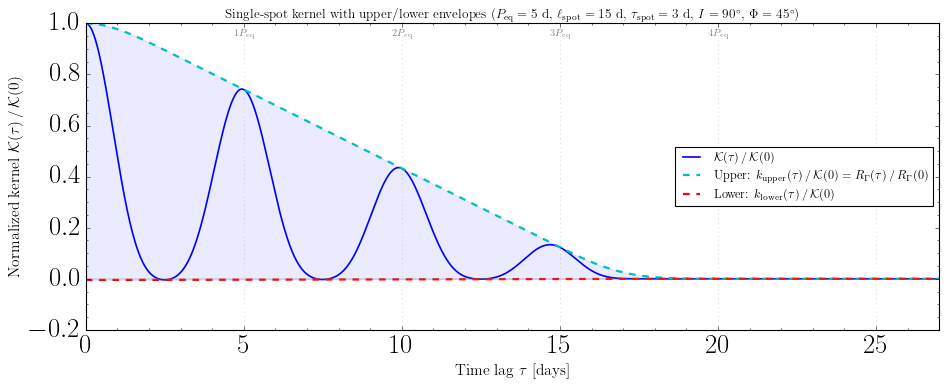

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(tau_arr, K_norm, color='C0', lw=1.5, label=r'$\mathcal{K}(\tau)\,/\,\mathcal{K}(0)$')
ax.plot(tau_arr, k_upper_norm, color='C3', lw=2, ls='--',
        label=r'Upper: $k_{\rm upper}(\tau)\,/\,\mathcal{K}(0) = R_\Gamma(\tau)\,/\,R_\Gamma(0)$')
ax.plot(tau_arr, k_lower_norm, color='C2', lw=2, ls='--',
        label=r'Lower: $k_{\rm lower}(\tau)\,/\,\mathcal{K}(0)$')
ax.fill_between(tau_arr, k_lower_norm, k_upper_norm, color='C0', alpha=0.08)

# Mark rotation period multiples
for m in range(1, int(tau_max_plot / P_eq) + 1):
    ax.axvline(m * P_eq, color='gray', ls=':', lw=0.6, alpha=0.4)
    if m <= 4:
        ax.text(m * P_eq, ax.get_ylim()[1] * 0.95, rf'${m}P_{{\rm eq}}$',
                ha='center', fontsize=9, color='gray')

ax.axhline(0, color='gray', ls='-', lw=0.4)
ax.set_xlabel(r'Time lag $\tau$ [days]', fontsize=14)
ax.set_ylabel(r'Normalized kernel $\mathcal{K}(\tau)\,/\,\mathcal{K}(0)$', fontsize=14)
ax.set_title(
    rf'Single-spot kernel with upper/lower envelopes  '
    rf'($P_{{\rm eq}}={P_eq:g}$ d, $\ell_{{\rm spot}}={ell_spot:g}$ d, $\tau_{{\rm spot}}={tau_spot:g}$ d, '
    rf'$I={np.degrees(inc):.0f}^\circ$, $\Phi={np.degrees(phi):.0f}^\circ$)',
    fontsize=12)
ax.set_xlim(0, tau_max_plot)
ax.legend(fontsize=11, loc='center right')   # keeps the m P_eq tick labels visible
ax.minorticks_on()

fig.tight_layout()
plt.show()

## Verify: the kernel touches its envelopes

At odd half-periods $\tau = (m + \tfrac12)P_{\rm eq}$, $\cos(\omega_0\tau) = -1$ and $\cos(2\omega_0\tau) = +1$, so the kernel should exactly equal the lower envelope $k_{\rm lower}$; at integer periods $\tau = mP_{\rm eq}$ both cosines are $+1$ and it should equal $k_{\rm upper}$. The kernel is evaluated exactly at these lags (not at the nearest grid point).

In [6]:
def K_at(tau):
    # K(tau) / K(0) evaluated exactly at the requested lags
    return kernel_components(tau, cn, omega0, ell_spot, tau_spot, alpha_max).sum(axis=0) / K0

# Odd half-periods: K = k_lower
half_periods = np.arange(1, int(2 * tau_max_plot / P_eq), 2) * P_eq / 2
half_periods = half_periods[half_periods < tau_max_plot]
k_lower_at = alpha_max**4 * R_Gamma(half_periods, ell_spot, tau_spot) * coeff_lower / K0
for hp, kv, lv in zip(half_periods, K_at(half_periods), k_lower_at):
    print(f"tau = {hp:6.2f} d (= {hp / P_eq:.1f} P_eq):  "
          f"K/K(0) = {kv:+.6f},  k_lower/K(0) = {lv:+.6f},  diff = {kv - lv:+.1e}")
assert np.allclose(K_at(half_periods), k_lower_at, rtol=0, atol=1e-12)

# Integer periods: K = k_upper
print()
periods = np.arange(1, int(tau_max_plot / P_eq) + 1) * P_eq
k_upper_at = alpha_max**4 * R_Gamma(periods, ell_spot, tau_spot) * coeff_upper / K0
for pp, kv, uv in zip(periods, K_at(periods), k_upper_at):
    print(f"tau = {pp:6.2f} d (= {pp / P_eq:.1f} P_eq):  "
          f"K/K(0) = {kv:+.6f},  k_upper/K(0) = {uv:+.6f},  diff = {kv - uv:+.1e}")
assert np.allclose(K_at(periods), k_upper_at, rtol=0, atol=1e-12)

tau =   2.50 d (= 0.5 P_eq):  K/K(0) = -0.004183,  k_lower/K(0) = -0.004183,  diff = -5.3e-17
tau =   7.50 d (= 1.5 P_eq):  K/K(0) = -0.002741,  k_lower/K(0) = -0.002741,  diff = -1.6e-17
tau =  12.50 d (= 2.5 P_eq):  K/K(0) = -0.001298,  k_lower/K(0) = -0.001298,  diff = -1.6e-17
tau =  17.50 d (= 3.5 P_eq):  K/K(0) = -0.000062,  k_lower/K(0) = -0.000062,  diff = -4.2e-19
tau =  22.50 d (= 4.5 P_eq):  K/K(0) = +0.000000,  k_lower/K(0) = -0.000000,  diff = +0.0e+00

tau =   5.00 d (= 1.0 P_eq):  K/K(0) = +0.740741,  k_upper/K(0) = +0.740741,  diff = +0.0e+00
tau =  10.00 d (= 2.0 P_eq):  K/K(0) = +0.432099,  k_upper/K(0) = +0.432099,  diff = +0.0e+00
tau =  15.00 d (= 3.0 P_eq):  K/K(0) = +0.123457,  k_upper/K(0) = +0.123457,  diff = +1.4e-17
tau =  20.00 d (= 4.0 P_eq):  K/K(0) = +0.000025,  k_upper/K(0) = +0.000025,  diff = -3.4e-21
tau =  25.00 d (= 5.0 P_eq):  K/K(0) = +0.000000,  k_upper/K(0) = +0.000000,  diff = +0.0e+00


## Check against the paper

1. **Recurrence heights** (Eq. `eq:peak_height_ratio`, Section `subsec:harmonic_n1`). For $\kappa = 0$, $\mathcal{K}(mP_{\rm eq})/\mathcal{K}(0) = R_\Gamma(mP_{\rm eq})/R_\Gamma(0)$, independent of $I$ and $\Phi$; the paper quotes $0.741$ and $0.432$ at one and two periods for $P_{\rm eq} = 5$ d, $\ell_{\rm spot} = 15$ d, $\tau_{\rm spot} = 3$ d, the parameters used here. Both lags lie in the linear regime $\tau_{\rm spot} < mP_{\rm eq} < \ell_{\rm spot}$, where Eq. `eq:linear_peak_decay` gives $(\ell_{\rm spot} + 2\tau_{\rm spot}/3 - mP_{\rm eq})/(\ell_{\rm spot} + 2\tau_{\rm spot}/5)$.
2. **Oscillation depth** (Eq. `eq:envelope_ratio`, Section `subsec:harmonic_n2`). With the latitude-averaged weights $\langle|c_n|^2\rangle_\Phi = \int_{-\pi/2}^{\pi/2}|c_n(\Phi)|^2 p(\Phi)\,d\Phi$ for uniform $p(\Phi) = 1/\pi$ (Gauss–Legendre quadrature), the paper quotes $k_{\rm lower}/k_{\rm upper} \approx -0.005$ edge-on, $+0.25$ at $I = 60^\circ$ and $+0.77$ at $I = 30^\circ$. Edge-on, $c_n = g_n\cos\Phi$ and $\langle|c_n|^2\rangle_\Phi = g_n^2/2$, so the single-spot depth computed above is independent of $\Phi$ and equals the latitude-averaged one. The same weights give the harmonic ratio $\mathcal{H} = \langle|c_2|^2\rangle_\Phi/\langle|c_1|^2\rangle_\Phi = (4/(3\pi))^2 \approx 0.18$ of Eq. `eq:harmonic_ratio`.

In [7]:
# 1. Recurrence heights, Eqs. eq:peak_height_ratio and eq:linear_peak_decay
for m, quoted in [(1, 0.741), (2, 0.432)]:
    tau_m = m * P_eq
    ratio = K_at(tau_m)[0]
    linear = (ell_spot + 2 * tau_spot / 3 - tau_m) / (ell_spot + 2 * tau_spot / 5)
    print(f"m = {m}:  K(m P_eq)/K(0) = {ratio:.4f},  "
          f"R_Gamma(m P_eq)/R_Gamma(0) = {R_Gamma(tau_m, ell_spot, tau_spot)[0] / R[0]:.4f},  "
          f"Eq. eq:linear_peak_decay = {linear:.4f}   (paper: {quoted})")
    assert np.isclose(ratio, linear) and np.isclose(round(ratio, 3), quoted)

# 2. Oscillation depth with latitude-averaged weights, Eq. eq:envelope_ratio
phi_nodes, phi_weights = _gauss_legendre_grid(200, -np.pi / 2, np.pi / 2)
phi_nodes = np.asarray(phi_nodes)
p_weights = np.asarray(phi_weights) / np.pi          # uniform p(Phi) = 1/pi


def cn2_lat_avg(inc_deg):
    # <|c_n|^2>_Phi for n = 0, 1, 2 under uniform p(Phi)
    I = np.radians(inc_deg)
    return np.array([np.sum(np.asarray(_cn_general_jax(n, I, phi_nodes))**2 * p_weights)
                     for n in range(3)])


def depth(w):
    return (w[0] - 2 * w[1] + 2 * w[2]) / (w[0] + 2 * w[1] + 2 * w[2])


print()
for inc_deg, quoted, decimals in [(90, -0.005, 3), (60, 0.25, 2), (30, 0.77, 2)]:
    w = cn2_lat_avg(inc_deg)
    print(f"I = {inc_deg:2d} deg:  <|c_n|^2> = {np.round(w, 5)},  k_lower/k_upper = {depth(w):+.4f}"
          f"  (paper: {quoted:+}),  <|c1|^2>/(4<|c2|^2>) = {w[1] / (4 * w[2]):.2f}")
    assert np.isclose(round(depth(w), decimals), quoted)
    assert w[1] >= 4 * w[2]          # k_lower is the minimum of the cosine sum

# Edge-on: <|c_n|^2> = g_n^2 / 2, single-spot depth = latitude-averaged depth, H = (4/(3 pi))^2
w90 = cn2_lat_avg(90)
assert np.allclose(w90, g**2 / 2, rtol=1e-6)
assert np.isclose(coeff_lower / coeff_upper, depth(w90))
H = w90[2] / w90[1]
print(f"\nEdge-on: single-spot depth = {coeff_lower / coeff_upper:+.5f}, latitude-averaged = {depth(w90):+.5f}")
print(f"H = <|c2|^2>/<|c1|^2> = {H:.4f}   (paper: (4/(3 pi))^2 = {(4 / (3 * np.pi))**2:.4f} ~ 0.18)")
assert np.isclose(H, (4 / (3 * np.pi))**2, rtol=1e-6)

m = 1:  K(m P_eq)/K(0) = 0.7407,  R_Gamma(m P_eq)/R_Gamma(0) = 0.7407,  Eq. eq:linear_peak_decay = 0.7407   (paper: 0.741)
m = 2:  K(m P_eq)/K(0) = 0.4321,  R_Gamma(m P_eq)/R_Gamma(0) = 0.4321,  Eq. eq:linear_peak_decay = 0.4321   (paper: 0.432)



I = 90 deg:  <|c_n|^2> = [0.05066 0.03125 0.00563],  k_lower/k_upper = -0.0047  (paper: -0.005),  <|c1|^2>/(4<|c2|^2>) = 1.39
I = 60 deg:  <|c_n|^2> = [0.09183 0.02902 0.00287],  k_lower/k_upper = +0.2540  (paper: +0.25),  <|c1|^2>/(4<|c2|^2>) = 2.53
I = 30 deg:  <|c_n|^2> = [0.19249 0.01262 0.00044],  k_lower/k_upper = +0.7691  (paper: +0.77),  <|c1|^2>/(4<|c2|^2>) = 7.14

Edge-on: single-spot depth = -0.00467, latitude-averaged = -0.00467
H = <|c2|^2>/<|c1|^2> = 0.1801   (paper: (4/(3 pi))^2 = 0.1801 ~ 0.18)
